In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps(remove_regions=False)

[15:30:06] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=804411;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=52482;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

## **Column Density Maps**

<>:44: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_4772\1879024664.py:44: SyntaxWarning: invalid escape sequence '\o'
  cbar.set_label('Mass [M$_\odot$/cm$^2$]', fontsize=13)


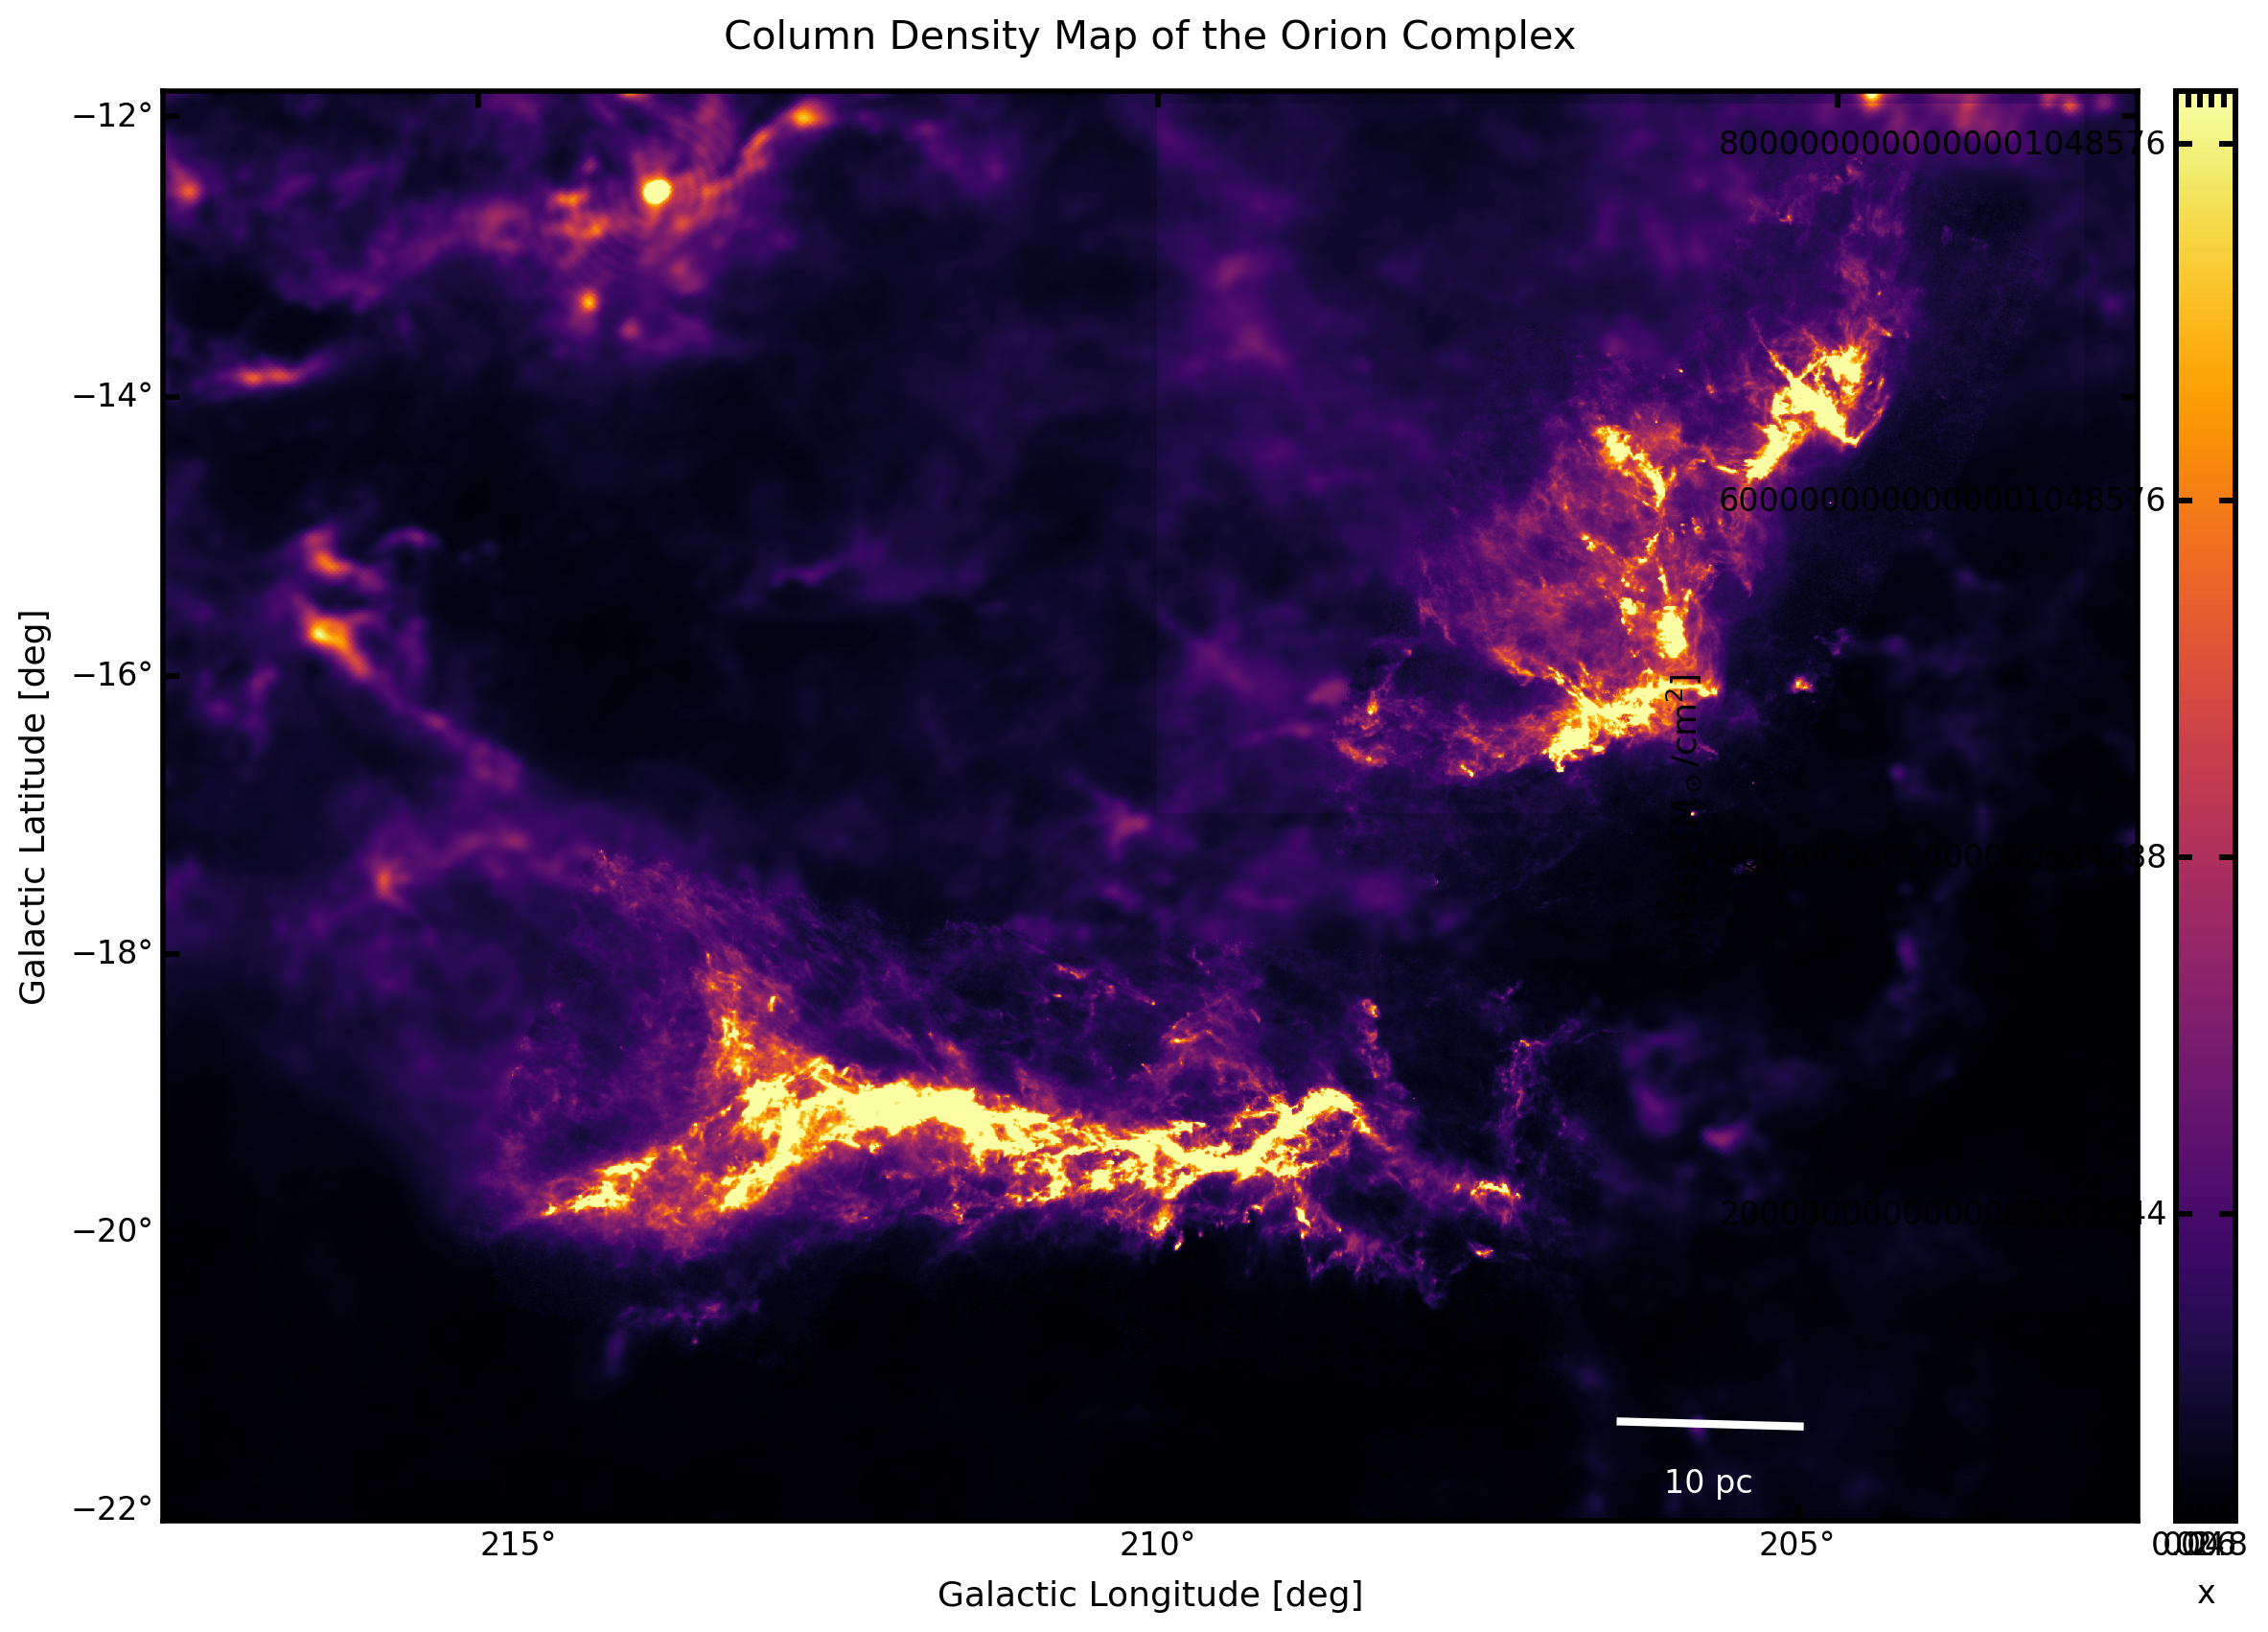

In [ ]:
from astropy.coordinates import SkyCoord
from mpl_toolkits.axes_grid1 import make_axes_locatable
import astropy.units as u
import matplotlib.patches as patches

l_min_A, l_max_A = 206, 217
b_min_A, b_max_A = -21, -17

min_coord_A = SkyCoord(l_min_A, b_min_A, frame='galactic', unit=u.deg)
max_coord_A = SkyCoord(l_max_A, b_max_A, frame='galactic', unit=u.deg)

min_pixel_A = wcs[:][:][0].world_to_pixel(min_coord_A)
max_pixel_A = wcs[:][:][0].world_to_pixel(max_coord_A)

l_min_B, l_max_B = 203, 210
b_min_B, b_max_B = -17, -12

min_coord_B = SkyCoord(l_min_B, b_min_B, frame='galactic', unit=u.deg)
max_coord_B = SkyCoord(l_max_B, b_max_B, frame='galactic', unit=u.deg)

min_pixel_B = wcs[:][:][0].world_to_pixel(min_coord_B)
max_pixel_B = wcs[:][:][0].world_to_pixel(max_coord_B)

min_value = np.percentile(N_H2, 1)  # 2nd percentile
max_value = np.percentile(N_H2, 99)  # 98th percentile

plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map with imshow
sp = ax.imshow(N_H2, vmin=min_value, vmax=max_value, interpolation=None, origin='lower', cmap = 'inferno') # from the perceptually uniform sequential colormaps
ax.set_title("Column Density Map of the Orion Complex", fontsize=15, pad=16)

# Add grid and colorbar
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)

# Adjust the colorbar to be the same height as the map using an inset axes
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.2)
cbar = plt.colorbar(sp, cax=cax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Mass [M$_\odot$/cm$^2$]', fontsize=13)

# Define the rectangles for Orion A and B
# Rectangle for Orion A
width_A = max_pixel_A[0] - min_pixel_A[0]
height_A = max_pixel_A[1] - min_pixel_A[1]
rect_A = patches.Rectangle((min_pixel_A[0], min_pixel_A[1]), width_A, height_A, 
                           linewidth=1.5, edgecolor='white', facecolor='none')
# ax.add_patch(rect_A)

# Rectangle for Orion B
width_B = max_pixel_B[0] - min_pixel_B[0]
height_B = max_pixel_B[1] - min_pixel_B[1]
rect_B = patches.Rectangle((min_pixel_B[0], min_pixel_B[1]), width_B, height_B, 
                           linewidth=1.5, edgecolor='blue', facecolor='none')
# ax.add_patch(rect_B)

# scale_bar
# Compute the angle corresponding to 10 pc at the distance of the galactic center
gc_distance = 412 * u.pc
scalebar_length = 10 * u.pc
scalebar_angle = (scalebar_length / gc_distance).to(
    u.deg, equivalencies=u.dimensionless_angles()
)

# Define values with units
y = -21.5 * u.deg
xmin = 205 * u.deg
xmax = (205 * u.deg + scalebar_angle)

# Convert to degrees as floats
y_deg = y.to(u.deg).value
xmin_deg = xmin.to(u.deg).value
xmax_deg = xmax.to(u.deg).value

# Plot the line without units in hlines
ax.plot([xmin_deg, xmax_deg], [y_deg, y_deg], transform=ax.get_transform('world'), color='white', linewidth=3)
ax.text((xmin_deg + xmax_deg) / 2, y_deg - 0.5, "10 pc", transform=ax.get_transform('world'), color='white', ha='center', fontsize=12)

plt.show()

## **Mass Maps**

<>:25: SyntaxWarning: invalid escape sequence '\o'
<>:25: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_4772\2065429914.py:25: SyntaxWarning: invalid escape sequence '\o'
  cbar.set_label('Mass [M$_\odot$/cm$^2$]', fontsize=13)


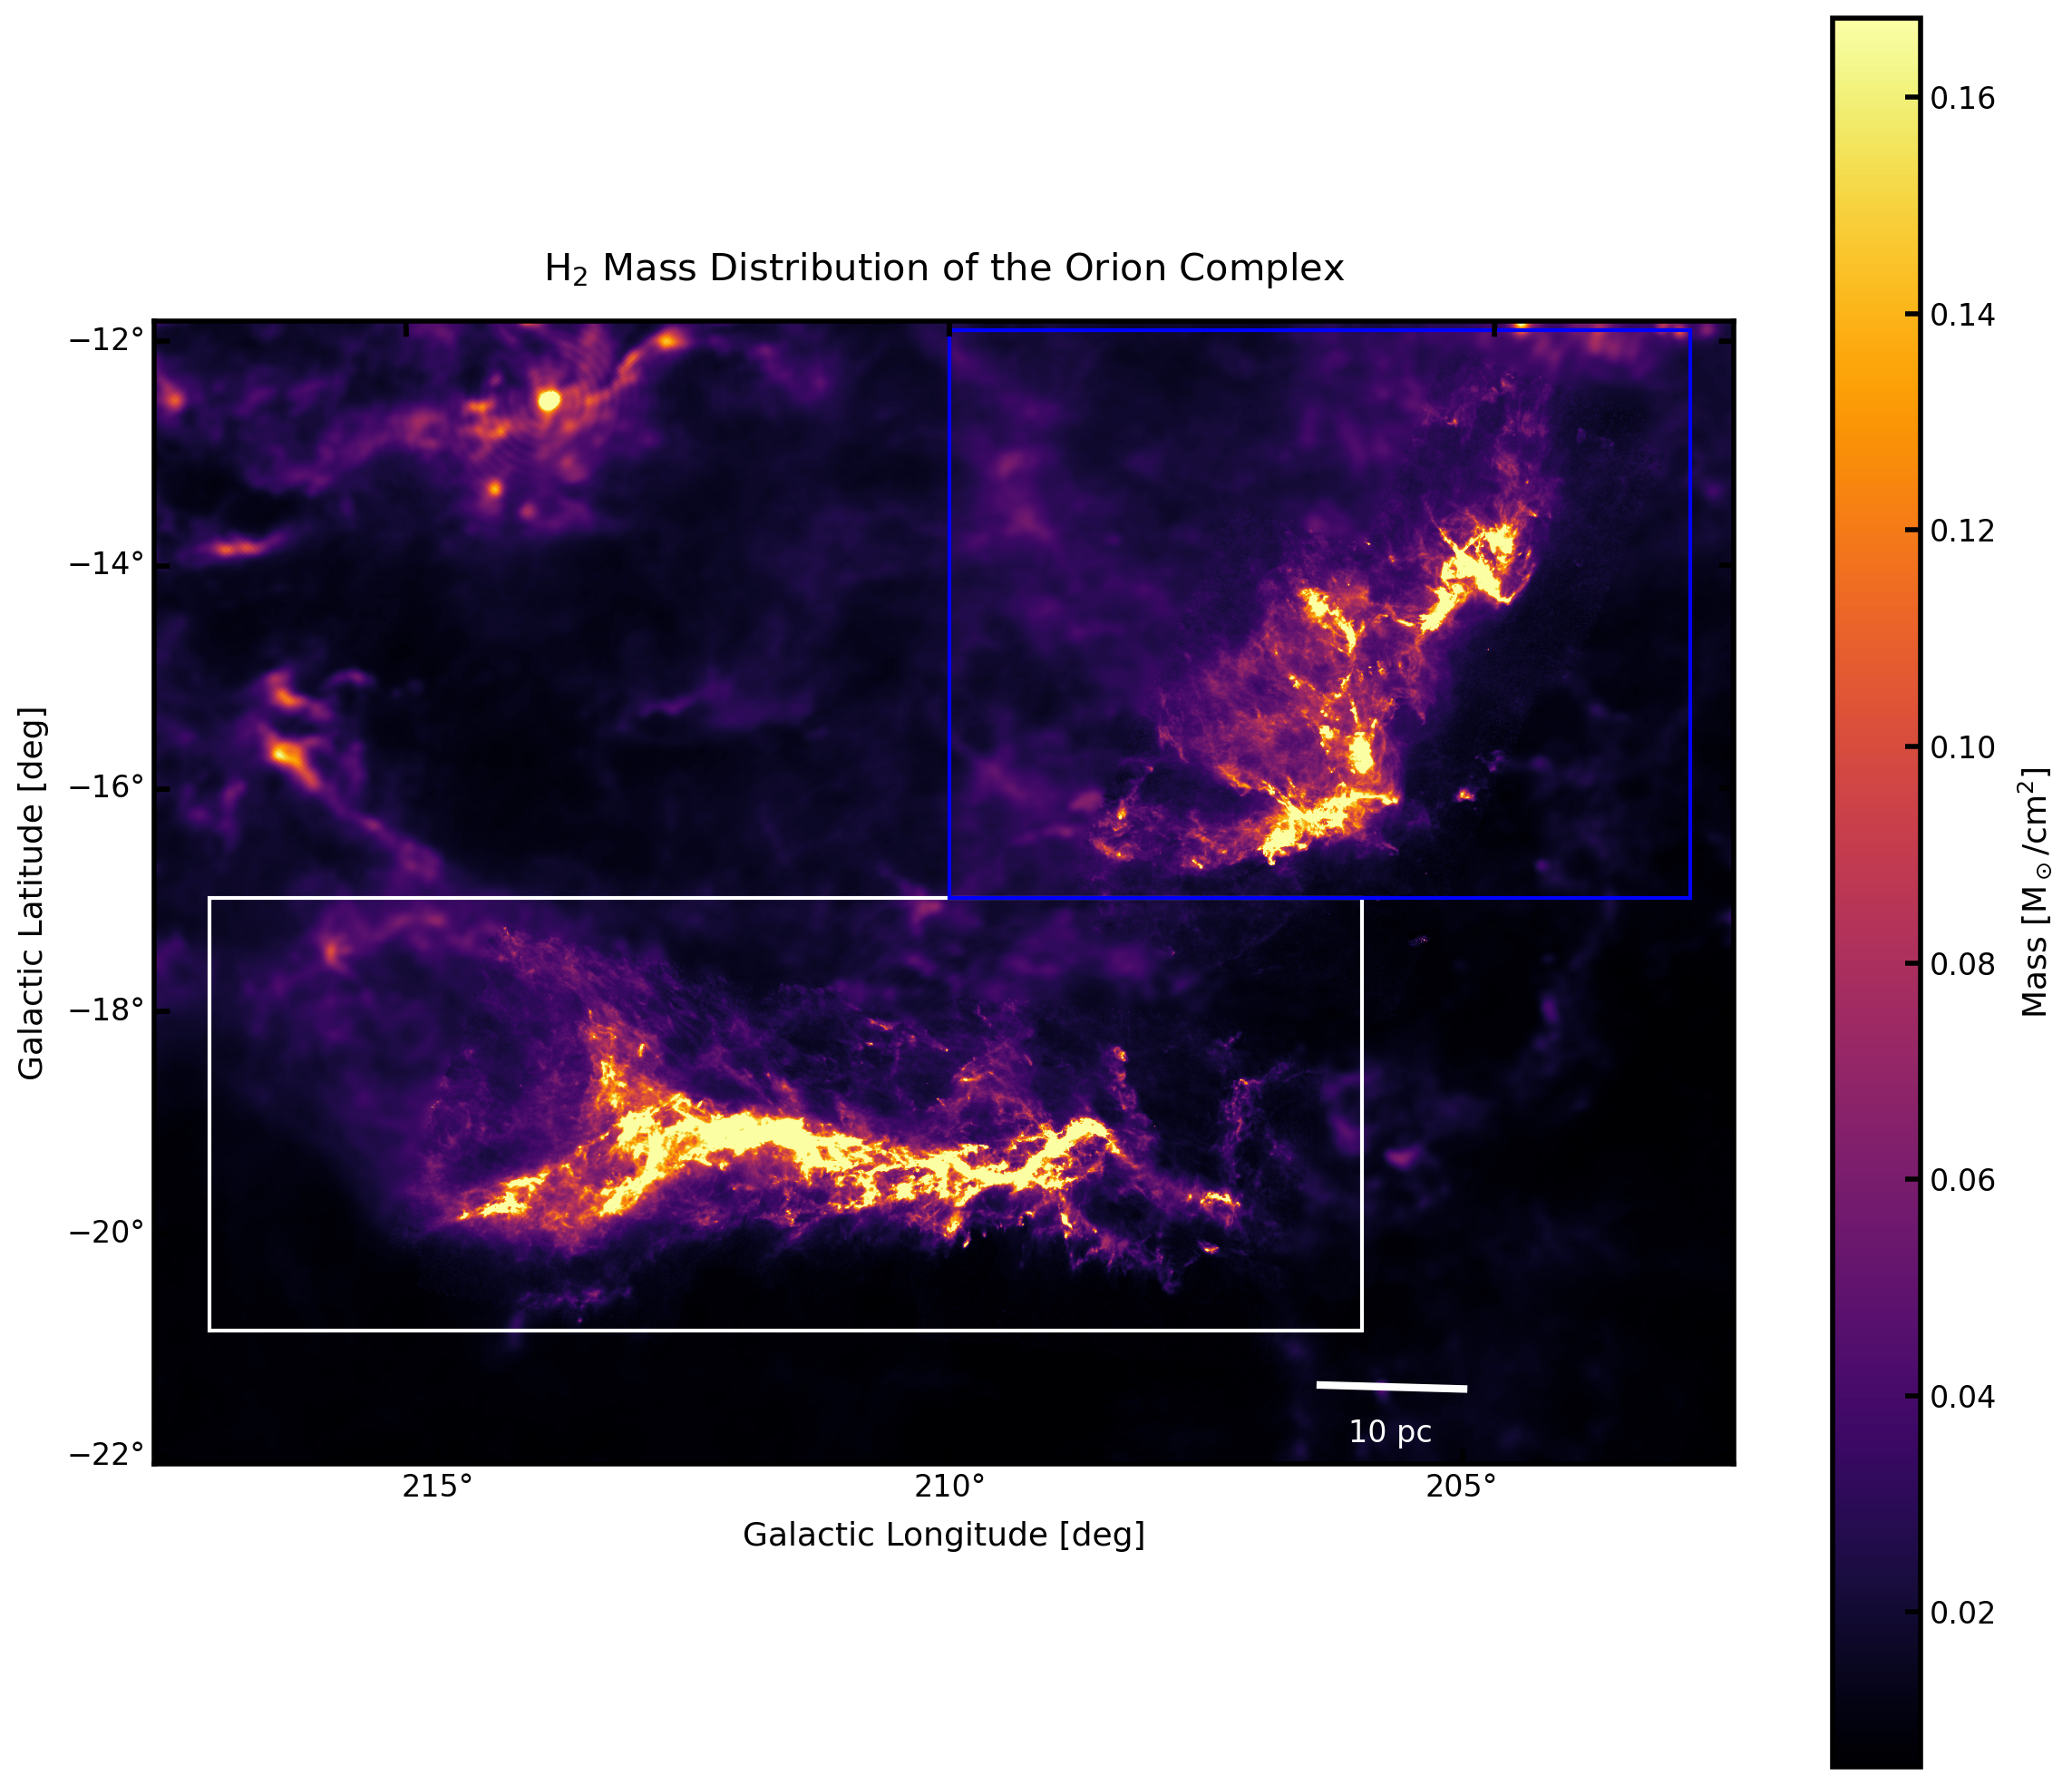

Orion A Mass (x 10**4):  8.617752860935793
Orion B Mass (x 10**4):  7.020336756176918
Orion A + Orion B Mass (x 10**5):  1.563808961711271
Overall map mass (x 10**5) 2.2635126639919614
Average Orion A Mass:  0.036380001067773074
Highest Orion A Mass (in a pixel):  9.486631839285888


In [3]:
# Mass Maps
M_H2_OA = convert_to_mass(N_H2_OA)
M_H2_OB = convert_to_mass(N_H2_OB)
M_H2 = convert_to_mass(N_H2)

# Both at the same time

min_value = np.percentile(M_H2, 1)  # 2nd percentile
max_value = np.percentile(M_H2, 99)  # 98th percentile

plt.figure(figsize=(12, 10))
ax = plt.subplot(111, projection=wcs[0])

# Plot the map with imshow
sp = ax.imshow(M_H2, vmin=min_value, vmax=max_value, interpolation=None, origin='lower', cmap = 'inferno') # from the perceptually uniform sequential colormaps
ax.set_title("H$_2$ Mass Distribution of the Orion Complex", fontsize=15, pad=16)

# Add grid and colorbar
ax.set_xlabel("Galactic Longitude [deg]", fontsize=13)
ax.set_ylabel("Galactic Latitude [deg]", fontsize=13)

fig = plt.gcf()  # Get the current figure
cbar = fig.colorbar(sp)  # Label the colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Mass [M$_\odot$/cm$^2$]', fontsize=13)

# Define the rectangles for Orion A and B
# Rectangle for Orion A
width_A = max_pixel_A[0] - min_pixel_A[0]
height_A = max_pixel_A[1] - min_pixel_A[1]
rect_A = patches.Rectangle((min_pixel_A[0], min_pixel_A[1]), width_A, height_A, 
                           linewidth=1.5, edgecolor='white', facecolor='none')
ax.add_patch(rect_A)

# Rectangle for Orion B
width_B = max_pixel_B[0] - min_pixel_B[0]
height_B = max_pixel_B[1] - min_pixel_B[1]
rect_B = patches.Rectangle((min_pixel_B[0], min_pixel_B[1]), width_B, height_B, 
                           linewidth=1.5, edgecolor='blue', facecolor='none')
ax.add_patch(rect_B)

# scale_bar
# Compute the angle corresponding to 10 pc at the distance of the galactic center
gc_distance = 412 * u.pc
scalebar_length = 10 * u.pc
scalebar_angle = (scalebar_length / gc_distance).to(
    u.deg, equivalencies=u.dimensionless_angles()
)

# Define values with units
y = -21.5 * u.deg
xmin = 205 * u.deg
xmax = (205 * u.deg + scalebar_angle)

# Convert to degrees as floats
y_deg = y.to(u.deg).value
xmin_deg = xmin.to(u.deg).value
xmax_deg = xmax.to(u.deg).value

# Plot the line without units in hlines
ax.plot([xmin_deg, xmax_deg], [y_deg, y_deg], transform=ax.get_transform('world'), color='white', linewidth=3)
ax.text((xmin_deg + xmax_deg) / 2, y_deg - 0.5, "10 pc", transform=ax.get_transform('world'), color='white', ha='center', fontsize=12)

plt.show()

# Orion A and Orion B stats
print("Orion A Mass (x 10**4): ", np.sum(M_H2_OA)/10**4)
print("Orion B Mass (x 10**4): ", np.sum(M_H2_OB)/10**4)
print("Orion A + Orion B Mass (x 10**5): ", (np.sum(M_H2_OA) + np.sum(M_H2_OB))/10**5)
print("Overall map mass (x 10**5)", np.sum(M_H2)/10**5)

print("Average Orion A Mass: ", np.mean(M_H2_OA))
print("Highest Orion A Mass (in a pixel): ", np.max(M_H2_OA))

## **Others**

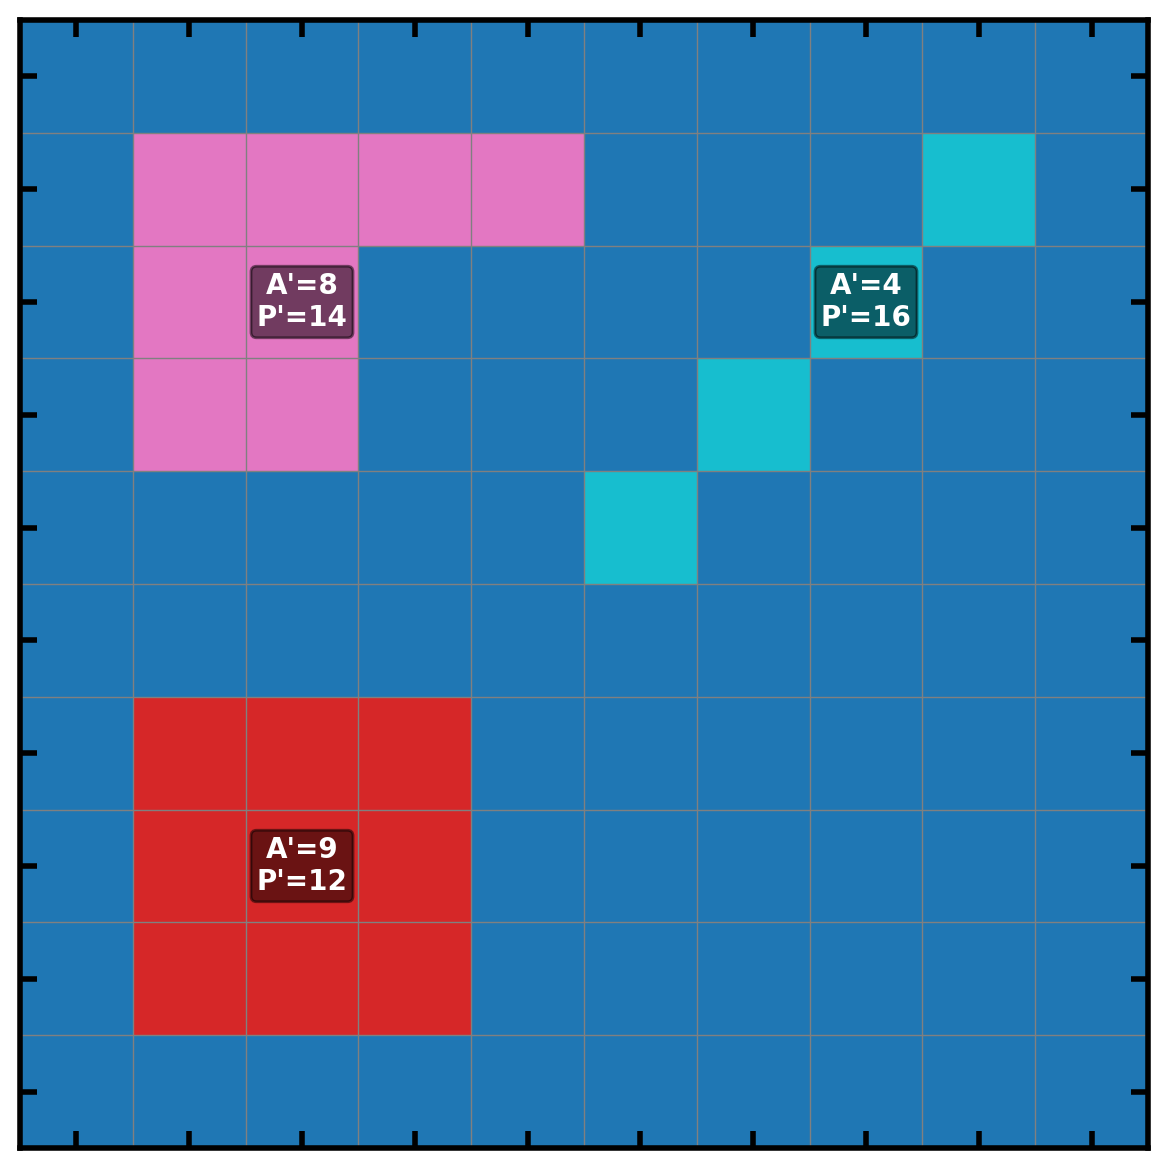

In [4]:
import numpy as np
from matplotlib.patches import Rectangle

import matplotlib.pyplot as plt

# Create a blank grid
grid_size = 10
grid = np.zeros((grid_size, grid_size), dtype=int)

# Draw a few shapes: a square, an L-shape, and a diagonal line
# Square
grid[1:4, 1:4] = 1

# L-shape
grid[6:9, 1:3] = 2
grid[8, 1:5] = 2

# Diagonal line
for i in range(5, 9):
    grid[i, i] = 3

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(grid, cmap='tab10', origin='lower')

# Draw grid lines
for i in range(grid_size + 1):
    ax.axhline(i - 0.5, color='gray', linewidth=0.5)
    ax.axvline(i - 0.5, color='gray', linewidth=0.5)

# Annotate area and perimeter for each shape
def count_area_perimeter(mask):
    area = np.sum(mask)
    perimeter = 0
    for x in range(mask.shape[0]):
        for y in range(mask.shape[1]):
            if mask[x, y]:
                # Check 4-neighbors
                for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                    nx, ny = x+dx, y+dy
                    if nx < 0 or nx >= mask.shape[0] or ny < 0 or ny >= mask.shape[1] or not mask[nx, ny]:
                        perimeter += 1
    return area, perimeter

shapes = {1: "Square", 2: "L-shape", 3: "Diagonal"}
colors = {1: 'black', 2: 'black', 3: 'black'}
positions = {1: (2, 2), 2: (7, 2), 3: (7, 7)}

for val, name in shapes.items():
    mask = (grid == val)
    area, perimeter = count_area_perimeter(mask)
    x, y = positions[val]
    ax.text(y, x, f"A'={area}\nP'={perimeter}", color='white', ha='center', va='center', fontsize=10, fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2'))

ax.set_xticks(np.arange(grid_size))
ax.set_yticks(np.arange(grid_size))
ax.set_xticklabels([])
ax.set_yticklabels([])
# ax.set_title("Area (A) and Perimeter (P) for Example Shapes", fontsize=14)
plt.tight_layout()
plt.show()

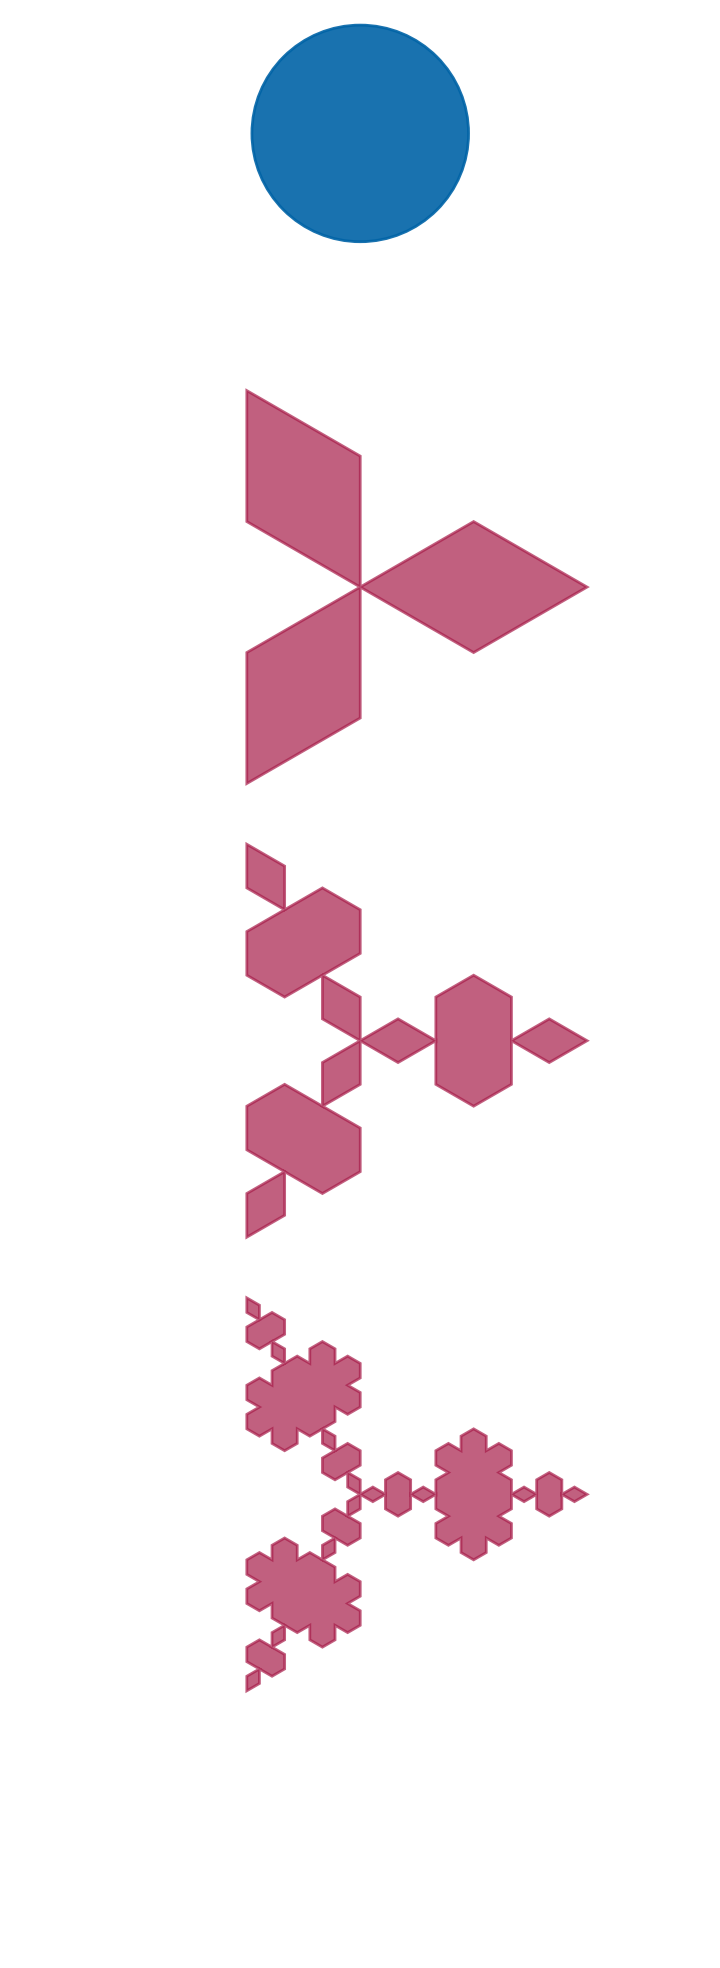

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from math import pi

def koch_snowflake(order, scale=10):
    def _koch_snowflake_complex(order):
        """Generate Koch snowflake as complex numbers."""
        if order == 0:
            angles = np.array([0, 2*np.pi/3, 4*np.pi/3])
            return scale * np.exp(1j * angles)
        else:
            prev = _koch_snowflake_complex(order - 1)
            new = []
            for i in range(len(prev)):
                z1 = prev[i]
                z2 = prev[(i + 1) % len(prev)]
                dz = z2 - z1
                new += [
                    z1,
                    z1 + dz / 3,
                    z1 + dz / 3 + (dz / 3) * np.exp(1j * np.pi / 3),
                    z1 + dz * 2 / 3
                ]
            return np.array(new)
    pts = _koch_snowflake_complex(order)
    pts = np.append(pts, pts[0])  # close the loop
    return np.real(pts), np.imag(pts)

# Set up figure
fig, ax = plt.subplots(figsize=(5, 10))  # Taller aspect for vertical stacking

# Circle parameters
triangle_side = 10
initial_perimeter = 3 * triangle_side
circle_radius = initial_perimeter / (2 * pi)

# Add circle (top)
circle = Circle((0, 80), circle_radius, color='#0063A6', alpha=0.9, label='Circle (max area)')
ax.add_patch(circle)

# Add Koch snowflakes underneath with vertical spacing
orders = [1, 2, 3]
colors = ['lightcoral', 'salmon', 'tomato', 'orangered']
vertical_spacing = 20  # Space between each shape

for i, order in enumerate(orders):
    x, y = koch_snowflake(order, scale=triangle_side)
    y_offset = 60 - i * vertical_spacing  # Stack downward
    ax.fill(x, y + y_offset, color="#A71C49", alpha=0.7, label=f'Koch order {order}')

# Final formatting
ax.set_aspect('equal')
ax.set_xlim(-15, 15)
ax.set_ylim(0, 85)
ax.axis('off')
# ax.set_title('Same Perimeter — Different Areas', fontsize=14, pad=20)
# ax.legend(loc='lower center', fontsize=9)
plt.tight_layout()
plt.show()